# Milestone 4: Evaluation & Analysis

**Scope of this notebook:** 4.1 Model Evaluation, 4.2 Model Comparison, 4.3 Sentiment Analysis, 4.4 Visualizations, 4.5 Interpretation.

This builds directly on the outputs from Milestone 3 (preprocessing/TF-IDF) and the model training already done by the team:
- data/labeled/final_labeled_dataset.csv — the cleaned, labeled dataset (2511 headlines)
- data/labeled/sentiment_predictions.csv — true sentiment + Logistic Regression & SVM predictions on every headline
- data/labeled/naive_bayes_predicted_sentiments.csv — true sentiment + Naive Bayes predictions on every headline
- models/model_comparison.csv — the metrics summary the team already generated

We'll re-derive the held-out test set (same random_state=42, same 80/20 split the team used) so our Accuracy/Precision/Recall/F1/confusion matrices are honest — not inflated by including training rows.

## Step 1: Setup — upload files

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

from google.colab import files
uploaded = files.upload()# sentiment_predictions.csv

uploaded = files.upload()# naive_bayes_predicted_sentiments.csv

uploaded = files.upload()# model_comparison.csv



Saving sentiment_predictions.csv to sentiment_predictions (1).csv


Saving naive_bayes_predicted_sentiments.csv to naive_bayes_predicted_sentiments.csv


Saving model_comparison.csv to model_comparison (1).csv


In [6]:
preds = pd.read_csv("sentiment_predictions.csv")
nb_preds = pd.read_csv("naive_bayes_predicted_sentiments.csv")
team_comparison = pd.read_csv("model_comparison.csv")

# sanity check: rows should line up 1:1 before we merge on position
assert len(preds) == len(nb_preds), "row count mismatch between prediction files"
assert (preds["headline"].values == nb_preds["headline"].values).all(), "headlines are not aligned between files"

# bring the Naive Bayes prediction column into one combined dataframe
df = preds.copy()
df["predicted_sentiment_naive_bayes"] = nb_preds["predicted_sentiment_naive_bayes"]

print(df.shape)
df.head()

(2511, 9)


,source,headline,published,link,sentiment,sentiment_encoded,predicted_sentiment_log_reg,predicted_sentiment_svm,predicted_sentiment_naive_bayes
0,Business Daily,KBL returns to court over alleged corruption i...,"Thu, 23 Jul 2026 13:38:53 GMT",https://www.businessdailyafrica.com/bd/corpora...,negative,0,negative,negative,negative
1,Citizen Digital,India's Gen Z protesters adapt to internet shu...,7/24/2026 23:51,https://citizen.digital/article/indias-gen-z-p...,negative,0,negative,negative,negative
2,Gma News Online,"Who is Karim Khan, the barrister at the center...",7/24/2026 22:40,https://www.gmanetwork.com/news/topstories/wor...,negative,0,negative,negative,negative
3,Kahawa Tungu,Body found dumped along Nairobi–Naivasha Highw...,"Sat, 25 Jul 2026 05:18:51 +0000",https://kahawatungu.com/body-found-dumped-alon...,negative,0,negative,negative,negative
4,Kahawa Tungu,"Two including Italian killed, two injured in R...","Sat, 25 Jul 2026 05:15:51 +0000",https://kahawatungu.com/two-including-italian-...,negative,0,negative,negative,negative


## 4.1 Model Evaluation

### Re-creating the held-out test set

The team's training script (`compare_models.py`) split the labeled data 80/20 with `random_state=42`, stratified by sentiment, trained on the 80%, and evaluated on the 20%. The prediction files we just loaded have predictions for **every** headline (including ones each model was trained on), so if we compute accuracy over all 2511 rows it will look better than it really is (data leakage).

To get honest numbers, we reproduce the exact same split here and only score the test rows.

In [7]:
train_idx, test_idx = train_test_split(
    df.index,
    test_size=0.20,
    random_state=42,
    stratify=df["sentiment"],
)

test_df = df.loc[test_idx].copy()
print(f"Test set: {len(test_df)} headlines (out of {len(df)} total)")
test_df["sentiment"].value_counts()

Test set: 503 headlines (out of 2511 total)


,count
sentiment,
negative,228
positive,189
neutral,86


### Accuracy, Precision, Recall, F1 for each model

Using macro-averaged Precision/Recall/F1 (treats all 3 classes equally, which matters here since `neutral` is the smallest class).

In [8]:
model_pred_cols = {
    "Logistic Regression": "predicted_sentiment_log_reg",
    "Linear SVM": "predicted_sentiment_svm",
    "Naive Bayes": "predicted_sentiment_naive_bayes",
}

y_true = test_df["sentiment"]
class_labels = sorted(y_true.unique())

results = []
confusion_matrices = {}

for model_name, col in model_pred_cols.items():
    y_pred = test_df[col]

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
    rec = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)

    results.append({"Model": model_name, "Accuracy": acc, "Precision": prec, "Recall": rec, "Macro F1": f1})
    confusion_matrices[model_name] = confusion_matrix(y_true, y_pred, labels=class_labels)

    print("=" * 60)
    print(model_name)
    print("=" * 60)
    print(classification_report(y_true, y_pred, zero_division=0))
    print()

our_results = pd.DataFrame(results).round(3)
our_results

Logistic Regression
              precision    recall  f1-score   support

    negative       0.73      0.85      0.79       228
     neutral       0.61      0.33      0.42        86
    positive       0.75      0.76      0.75       189

    accuracy                           0.73       503
   macro avg       0.70      0.65      0.66       503
weighted avg       0.72      0.73      0.71       503


Linear SVM
              precision    recall  f1-score   support

    negative       0.74      0.85      0.79       228
     neutral       0.61      0.35      0.44        86
    positive       0.75      0.76      0.76       189

    accuracy                           0.73       503
   macro avg       0.70      0.65      0.66       503
weighted avg       0.72      0.73      0.72       503


Naive Bayes
              precision    recall  f1-score   support

    negative       0.69      0.86      0.76       228
     neutral       0.71      0.20      0.31        86
    positive       0.72      0

,Model,Accuracy,Precision,Recall,Macro F1
0,Logistic Regression,0.728,0.697,0.646,0.656
1,Linear SVM,0.730,0.700,0.652,0.663
2,Naive Bayes,0.704,0.707,0.601,0.603


**Checkpoint:** compare `our_results` above against `team_comparison` (loaded from `model_comparison.csv`) — they should be close (small differences are fine, since the team's numbers came from a GridSearchCV-tuned fit, this one just reuses their saved predictions on the same test split).

In [9]:
print("Our re-computed metrics:")
display(our_results)
print("\nTeam's saved metrics (model_comparison.csv):")
display(team_comparison)

Our re-computed metrics:


,Model,Accuracy,Precision,Recall,Macro F1
0,Logistic Regression,0.728,0.697,0.646,0.656
1,Linear SVM,0.730,0.700,0.652,0.663
2,Naive Bayes,0.704,0.707,0.601,0.603



Team's saved metrics (model_comparison.csv):


,Model,Accuracy,Precision,Recall,Macro F1
0,Linear SVM,0.710,0.677,0.644,0.653
1,Logistic Regression,0.714,0.683,0.642,0.652
2,Naive Bayes,0.688,0.666,0.596,0.601


### Confusion matrix — one per model

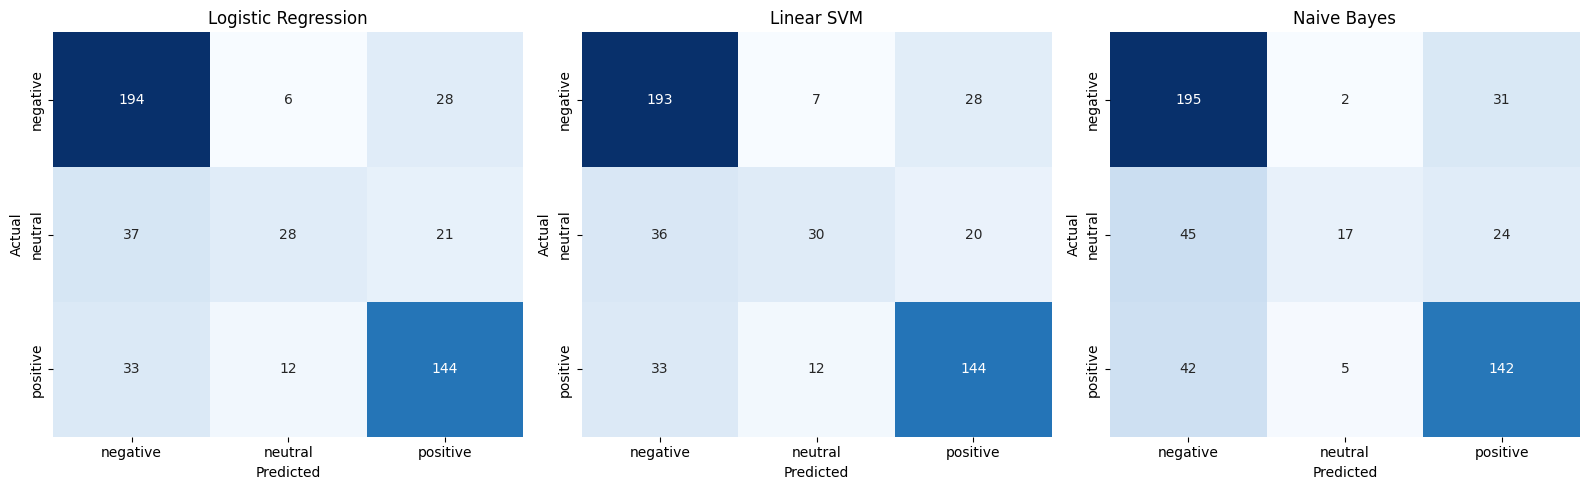

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (model_name, cm) in zip(axes, confusion_matrices.items()):
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_labels, yticklabels=class_labels, ax=ax, cbar=False)
    ax.set_title(model_name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()